<a href="https://colab.research.google.com/github/Nasuz092/Google-Colab-Sentimen-Analisis-/blob/main/Sentimen_Analisis_2_0_(Youtube_Comment)_VADER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROSES CLEANSING DATA**

In [164]:
!pip install nltk

In [165]:
#import modul
import pandas as pd
import numpy as np
import regex as re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [166]:
df = pd.read_csv('https://raw.githubusercontent.com/Nasuz092/Dataset-Twitter/refs/heads/main/yt-comments-lol2025%20(4).csv', sep=',')
df .head(3)

,publishedAt,authorDisplayName,textDisplay,likeCount
0,2025-01-08T13:12:36Z,@inexcess4083,Darius its a till lindemann ?,0.0
1,2025-01-08T13:12:11Z,@Jesuisla7,sortez nous des épisodes tellement c’est incro...,0.0
2,2025-01-08T13:12:07Z,@joaovitorlimamoura407,I wanna see more the Katarina riot games pleas...,0.0


In [167]:
# Menghapus Kolom yang tidak digunakan
df = df.drop(columns=['publishedAt',	'authorDisplayName'], axis=1)

# Menghapus data yang memiliki nilai NaN dalam kolom tertentu
df = df.dropna(subset=['textDisplay',	'likeCount'])

# Menghapus nilai yang Duplikat atau sama persis
df = df.drop_duplicates(subset=['textDisplay'])
df

,textDisplay,likeCount
0,Darius its a till lindemann ?,0.0
1,sortez nous des épisodes tellement c’est incro...,0.0
2,I wanna see more the Katarina riot games pleas...,0.0
3,mordekaiser por favor,1.0
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0
...,...,...
22742,"thats great and all, but i wanted realistic ma...",162.0
22743,@@cboymemes58 I love Arcane but at the same ti...,81.0
22744,@@Gradeient they literally do use different st...,225.0
22745,"@@Lesdrasill Well I agree to a degree, but eve...",13.0


In [168]:
import re
import unicodedata

def remove_pattern(Text, pattern):
    r = re.findall(pattern, str(Text))
    for i in r:
        Text = re.sub(i, '', str(Text))
    return Text
df['remove_user'] = np.vectorize(remove_pattern)(df['textDisplay'], "@[\w]*")

In [169]:
def cleaning(Text):
    Text = re.sub(r"<a\s+href='https:\/\/www\.youtube\.com\/watch\?v=[^']+(&t=[0-9ms]+)?'>[^<]+<\/a>", "", Text)
    Text = re.sub(r"<a\s+href='(?:https?:\/\/)?(?:www\.)?youtube\.com[^']*(&t=[0-9ms]+)?'>[^<]+<\/a>", "", Text)
    Text = re.sub(r"<br\s*\/?>", "", Text)
    Text = Text.replace("&#39;", "")
    Text = re.sub(r"&lrm;", "", Text)
    Text = re.sub(r"&zwnj;", "", Text)
    Text = re.sub(r'\s&amp\s', ' ', Text)
    Text = re.sub(r'$\w*', '', Text)
    Text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', ' ', Text)
    Text = re.sub(r"\d+", " ", str(Text))
    Text = re.sub(r"\s+", " ", str(Text))
    Text = re.sub(r'#', '', Text)
    Text = re.sub(r'\s\s+', ' ', Text)
    Text = re.sub(r'^b[\s]+', '', Text)
    Text = re.sub(r'^link[\s]+', '', Text)
    Text = re.sub(r"<\/?[a-z]+>", "", Text)
    Text = re.sub(r"<a\s+[^>]*>", "", Text)
    return Text

def remove_emoji(Text):
    emoji = re.compile("["
                        u"\U0001F600-\U0001F64F"  # emoticons
                        u"\U0001F300-\U0001F5FF"  # simbol & piktogram
                        u"\U0001F680-\U0001F6FF"  # transportasi & simbol peralatan
                        u"\U0001F1E0-\U0001F1FF"  # bendera negara
                        u"\U00002702-\U000027B0"  # simbol
                        u"\U000024C2-\U0001F251"  # emoji lainnya
                        "]+", flags=re.UNICODE)
    return emoji.sub(r'', Text)

df['cleaning'] = df['remove_user'].apply(cleaning)

In [170]:
def tokenize_with_quotes(text):
    tokens = word_tokenize(text)
    tokens_with_quotes = ['"' + token + '"' for token in tokens]
    return tokens_with_quotes

df['tokenized_Content'] = df['textDisplay'].apply(lambda x: tokenize_with_quotes(x))
df.head(6)

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"[""Darius"", ""its"", ""a"", ""till"", ""lindemann"", ""?""]"
1,sortez nous des épisodes tellement c’est incro...,0.0,sortez nous des épisodes tellement c’est incro...,sortez nous des épisodes tellement c’est incro...,"[""sortez"", ""nous"", ""des"", ""épisodes"", ""telleme..."
2,I wanna see more the Katarina riot games pleas...,0.0,I wanna see more the Katarina riot games pleas...,I wanna see more the Katarina riot games pleas...,"[""I"", ""wan"", ""na"", ""see"", ""more"", ""the"", ""Kata..."
3,mordekaiser por favor,1.0,mordekaiser por favor,mordekaiser por favor,"[""mordekaiser"", ""por"", ""favor""]"
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","[""The"", ""symbol"", ""Vlad"", ""and"", ""Le"", ""Blanc""..."
5,i dont understand how can some people say that...,0.0,i dont understand how can some people say that...,i dont understand how can some people say that...,"[""i"", ""dont"", ""understand"", ""how"", ""can"", ""som..."


In [171]:
df.isnull().sum()

,0
textDisplay,0
likeCount,0
remove_user,0
cleaning,0
tokenized_Content,0


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21823 entries, 0 to 22746
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   textDisplay        21823 non-null  object 
 1   likeCount          21823 non-null  float64
 2   remove_user        21823 non-null  object 
 3   cleaning           21823 non-null  object 
 4   tokenized_Content  21823 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1023.0+ KB


In [173]:
#Save Data yag sudah di cleasing ke gdrive
df.to_csv('Data_Cleaned.csv', index=False)

# **DOWNLOAD FILE HASIL CLEANSING (OPSIONAL)**
*Opsi tambahan untuk mendownload data yang sudah di cleansing sebelumnya*

In [ ]:
from google.colab import files

# Ganti nama filenya dengan nama file yang sudah di save di gdrive sebelumnya.
files.download('Data_Cleaned.csv')

#**PROSES LABELLING**

In [174]:
pip install vaderSentiment

In [175]:
import pandas as pd
import numpy as np
import nltk
nltk.downloader.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [176]:
# Sesuaikan dengan path file yang tadi sudah di save
# klik di bar icon folder > cari nama filenya > klik titi 3 atau klik kanan > pilih copy path > paste di antara tanda petik pada codingan di bawah [, sep=','])
df1 = pd.read_csv('/content/Data_Cleaned.csv', sep=',')
df1

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"['""Darius""', '""its""', '""a""', '""till""', '""linde..."
1,sortez nous des épisodes tellement c’est incro...,0.0,sortez nous des épisodes tellement c’est incro...,sortez nous des épisodes tellement c’est incro...,"['""sortez""', '""nous""', '""des""', '""épisodes""', ..."
2,I wanna see more the Katarina riot games pleas...,0.0,I wanna see more the Katarina riot games pleas...,I wanna see more the Katarina riot games pleas...,"['""I""', '""wan""', '""na""', '""see""', '""more""', '""..."
3,mordekaiser por favor,1.0,mordekaiser por favor,mordekaiser por favor,"['""mordekaiser""', '""por""', '""favor""']"
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","['""The""', '""symbol""', '""Vlad""', '""and""', '""Le""..."
...,...,...,...,...,...
21818,"thats great and all, but i wanted realistic ma...",162.0,"thats great and all, but i wanted realistic ma...","thats great and all, but i wanted realistic ma...","['""thats""', '""great""', '""and""', '""all""', '"",""'..."
21819,@@cboymemes58 I love Arcane but at the same ti...,81.0,cboymemes58 I love Arcane but at the same time...,cboymemes I love Arcane but at the same time I...,"['""@""', '""@""', '""cboymemes58""', '""I""', '""love""..."
21820,@@Gradeient they literally do use different st...,225.0,Gradeient they literally do use different styl...,Gradeient they literally do use different styl...,"['""@""', '""@""', '""Gradeient""', '""they""', '""lite..."
21821,"@@Lesdrasill Well I agree to a degree, but eve...",13.0,"Lesdrasill Well I agree to a degree, but every...","Lesdrasill Well I agree to a degree, but every...","['""@""', '""@""', '""Lesdrasill""', '""Well""', '""I""'..."


In [177]:
# Menghapus data yang null berdasarkan kolom 'cleaning'
df1 = df1.dropna(subset=['cleaning'])

In [178]:
# Menghapus duplikat text pada data berdasarkan kolom 'textDisplay'
df1 = df1.drop_duplicates(['cleaning'])

In [179]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21798 entries, 0 to 21822
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   textDisplay        21798 non-null  object 
 1   likeCount          21798 non-null  float64
 2   remove_user        21798 non-null  object 
 3   cleaning           21798 non-null  object 
 4   tokenized_Content  21798 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1021.8+ KB


In [180]:
# senti_indo = SentimentIntensityAnalyzer()

url = 'https://drive.google.com/file/d/1r13XQU2M6ugxRM0g-_fGOylEB1t2_XME/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]

# df_senti = pd.read_csv(path)
df_senti = pd.read_csv(path, sep=':', names=['word', 'value'])
# print(df_senti)

senti_dict = {}

for i in range (len(df_senti)):
  senti_dict[df_senti.iloc[i]['word']] = df_senti.iloc[i]['value']

In [181]:
senti_indo = SentimentIntensityAnalyzer()
senti_indo.lexicon.update(senti_dict)

In [182]:
def give_label_and_score(sentence):
    # Jika bukan angka, lakukan pelabelan sentimen menggunakan VADER
    senti_indo = SentimentIntensityAnalyzer()
    senti_indo.lexicon.update(senti_dict)
    nilai = senti_indo.polarity_scores(sentence)
    print(nilai)

    # Menentukan label
    if nilai['compound'] >= 0.3:
        label = "positif"
    elif nilai['compound'] <= -0.3:
        label = "negatif"
    else:
        label = "netral"

    # Mengembalikan label dan nilai compound
    return label, nilai['compound']

In [183]:
kal="good best banger died suck"
label = give_label_and_score(kal)
print(label)

{'neg': 0.452, 'neu': 0.06, 'pos': 0.488, 'compound': 0.1531}
('netral', 0.1531)


In [184]:
label_mc = []
compound_scores = []
for review in df1['cleaning']:
    get_label, get_score = give_label_and_score(review)
    label_mc.append(get_label)
    compound_scores.append(get_score)

Streaming output truncated to the last 5000 lines.
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.063, 'neu': 0.601, 'pos': 0.335, 'compound': 0.9009}
{'neg': 0.34, 'neu': 0.189, 'pos': 0.472, 'compound': 0.5859}
{'neg': 0.183, 'neu': 0.817, 'pos': 0.0, 'compound': -0.504}
{'neg': 0.227, 'neu': 0.773, 'pos': 0.0, 'compound': -0.7184}
{'neg': 0.128, 'neu': 0.872, 'pos': 0.0, 'compound': -0.296}
{'neg': 0.4, 'neu': 0.6, 'pos': 0.0, 'compound': -0.6124}
{'neg': 0.0, 'neu': 0.455, 'pos': 0.545, 'compound': 0.7906}
{'neg': 0.068, 'neu': 0.63, 'pos': 0.303, 'compound': 0.9873}
{'neg': 0.225, 'neu': 0.775, 'pos': 0.0, 'compound': -0.6199}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.75, 'neu': 0.25, 'pos': 0.0, 'compound': -0.4588}
{'neg': 0.0, 'neu': 0.444, 'pos': 0.556, 'compound': 0.7184}
{'neg': 0.162, 'neu': 0.714, 'pos': 0.124, 'compound': 0.0}
{'neg': 0.0, 'neu': 0.191, 'pos': 0.809, 'compound': 0.9406}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound'

In [185]:
df1['Label'] = label_mc
df1['compound_score'] = compound_scores
df1

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content,Label,compound_score
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"['""Darius""', '""its""', '""a""', '""till""', '""linde...",netral,0.0000
1,sortez nous des épisodes tellement c’est incro...,0.0,sortez nous des épisodes tellement c’est incro...,sortez nous des épisodes tellement c’est incro...,"['""sortez""', '""nous""', '""des""', '""épisodes""', ...",positif,0.6124
2,I wanna see more the Katarina riot games pleas...,0.0,I wanna see more the Katarina riot games pleas...,I wanna see more the Katarina riot games pleas...,"['""I""', '""wan""', '""na""', '""see""', '""more""', '""...",negatif,-0.7402
3,mordekaiser por favor,1.0,mordekaiser por favor,mordekaiser por favor,"['""mordekaiser""', '""por""', '""favor""']",positif,0.6124
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","['""The""', '""symbol""', '""Vlad""', '""and""', '""Le""...",netral,0.0000
...,...,...,...,...,...,...,...
21818,"thats great and all, but i wanted realistic ma...",162.0,"thats great and all, but i wanted realistic ma...","thats great and all, but i wanted realistic ma...","['""thats""', '""great""', '""and""', '""all""', '"",""'...",positif,0.9781
21819,@@cboymemes58 I love Arcane but at the same ti...,81.0,cboymemes58 I love Arcane but at the same time...,cboymemes I love Arcane but at the same time I...,"['""@""', '""@""', '""cboymemes58""', '""I""', '""love""...",positif,0.7935
21820,@@Gradeient they literally do use different st...,225.0,Gradeient they literally do use different styl...,Gradeient they literally do use different styl...,"['""@""', '""@""', '""Gradeient""', '""they""', '""lite...",positif,0.9136
21821,"@@Lesdrasill Well I agree to a degree, but eve...",13.0,"Lesdrasill Well I agree to a degree, but every...","Lesdrasill Well I agree to a degree, but every...","['""@""', '""@""', '""Lesdrasill""', '""Well""', '""I""'...",positif,0.9604


In [192]:
df1[df1['compound_score'] == 0.0000]

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content,Label,compound_score
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"['""Darius""', '""its""', '""a""', '""till""', '""linde...",netral,0.0
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","['""The""', '""symbol""', '""Vlad""', '""and""', '""Le""...",netral,0.0
9,Do we really need a 5 minute trailer? this goi...,0.0,Do we really need a 5 minute trailer? this goi...,Do we really need a minute trailer? this going...,"['""Do""', '""we""', '""really""', '""need""', '""a""', ...",netral,0.0
10,Totaly know in spin off or continue ARCANE...i...,0.0,Totaly know in spin off or continue ARCANE...i...,Totaly know in spin off or continue ARCANE...i...,"['""Totaly""', '""know""', '""in""', '""spin""', '""off...",netral,0.0
14,hueta,0.0,hueta,hueta,"['""hueta""']",netral,0.0
...,...,...,...,...,...,...,...
21813,🦌🦌🦌,0.0,🦌🦌🦌,🦌🦌🦌,"['""🦌🦌🦌""']",netral,0.0
21814,LETS GO LEBLANC,1.0,LETS GO LEBLANC,LETS GO LEBLANC,"['""LETS""', '""GO""', '""LEBLANC""']",netral,0.0
21815,love hate this game,2.0,love hate this game,love hate this game,"['""love""', '""hate""', '""this""', '""game""']",netral,0.0
21816,the empire will rise.,28.0,the empire will rise.,the empire will rise.,"['""the""', '""empire""', '""will""', '""rise""', '"".""']",netral,0.0


In [193]:
df1[df1['Label'] == "netral"]

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content,Label,compound_score
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"['""Darius""', '""its""', '""a""', '""till""', '""linde...",netral,0.0000
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","['""The""', '""symbol""', '""Vlad""', '""and""', '""Le""...",netral,0.0000
7,pure perfection,0.0,pure perfection,pure perfection,"['""pure""', '""perfection""']",netral,0.1779
9,Do we really need a 5 minute trailer? this goi...,0.0,Do we really need a 5 minute trailer? this goi...,Do we really need a minute trailer? this going...,"['""Do""', '""we""', '""really""', '""need""', '""a""', ...",netral,0.0000
10,Totaly know in spin off or continue ARCANE...i...,0.0,Totaly know in spin off or continue ARCANE...i...,Totaly know in spin off or continue ARCANE...i...,"['""Totaly""', '""know""', '""in""', '""spin""', '""off...",netral,0.0000
...,...,...,...,...,...,...,...
21813,🦌🦌🦌,0.0,🦌🦌🦌,🦌🦌🦌,"['""🦌🦌🦌""']",netral,0.0000
21814,LETS GO LEBLANC,1.0,LETS GO LEBLANC,LETS GO LEBLANC,"['""LETS""', '""GO""', '""LEBLANC""']",netral,0.0000
21815,love hate this game,2.0,love hate this game,love hate this game,"['""love""', '""hate""', '""this""', '""game""']",netral,0.0000
21816,the empire will rise.,28.0,the empire will rise.,the empire will rise.,"['""the""', '""empire""', '""will""', '""rise""', '"".""']",netral,0.0000


In [194]:
# Filter data dengan Label = "netral"
data_netral = df1[df1['Label'] == "netral"]

# Simpan ke CSV
data_netral.to_csv('data_netral.csv', index=False)  # `index=False` agar tidak menyimpan kolom index

In [188]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21798 entries, 0 to 21822
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   textDisplay        21798 non-null  object 
 1   likeCount          21798 non-null  float64
 2   remove_user        21798 non-null  object 
 3   cleaning           21798 non-null  object 
 4   tokenized_Content  21798 non-null  object 
 5   Label              21798 non-null  object 
 6   compound_score     21798 non-null  float64
dtypes: float64(2), object(5)
memory usage: 1.3+ MB


In [189]:
#Save Data yag sudah di cleasing ke gdrive
df1.to_csv('Data_Cleaned+Label.csv', index=False)

# **VISUALISASI**

#### **Sentimen Analisis**

In [190]:
# Sesuaikan dengan path file yang tadi sudah di save
# klik di bar icon folder > cari nama filenya > klik titi 3 atau klik kanan > pilih copy path > paste di antara tanda petik pada codingan di bawah [, sep=','])
df2 = pd.read_csv('/content/Data_Cleaned+Label.csv', sep=',')
df2 .head()

,textDisplay,likeCount,remove_user,cleaning,tokenized_Content,Label,compound_score
0,Darius its a till lindemann ?,0.0,Darius its a till lindemann ?,Darius its a till lindemann ?,"['""Darius""', '""its""', '""a""', '""till""', '""linde...",netral,0.0000
1,sortez nous des épisodes tellement c’est incro...,0.0,sortez nous des épisodes tellement c’est incro...,sortez nous des épisodes tellement c’est incro...,"['""sortez""', '""nous""', '""des""', '""épisodes""', ...",positif,0.6124
2,I wanna see more the Katarina riot games pleas...,0.0,I wanna see more the Katarina riot games pleas...,I wanna see more the Katarina riot games pleas...,"['""I""', '""wan""', '""na""', '""see""', '""more""', '""...",negatif,-0.7402
3,mordekaiser por favor,1.0,mordekaiser por favor,mordekaiser por favor,"['""mordekaiser""', '""por""', '""favor""']",positif,0.6124
4,"The symbol Vlad and Le Blanc are looking at, I...",1.0,"The symbol Vlad and Le Blanc are looking at, I...","The symbol Vlad and Le Blanc are looking at, I...","['""The""', '""symbol""', '""Vlad""', '""and""', '""Le""...",netral,0.0000


In [191]:
pos = (df2['Label'] == 'positif').sum()
neg = (df2['Label'] == 'negatif').sum()
neu = (df2['Label'] == 'netral').sum()
print('jumlah data sentimen positif:', pos, '\njumlah data sentimen negatif:', neg, '\njumlah data sentimen neutral:', neu)

jumlah data sentimen positif: 8485 
jumlah data sentimen negatif: 3193 
jumlah data sentimen neutral: 10120


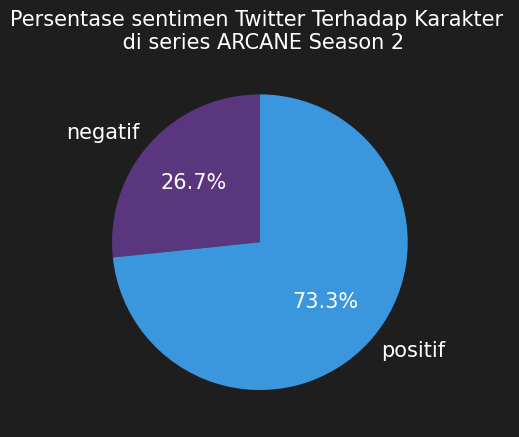

In [136]:
#Import Library
import matplotlib.pyplot as plt

# Data
labels = ['negatif', 'positif']
sizes = [neg, pos]
colors = ['#5A367E', '#3A96DD', '#']


# Membuat pie chart
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 15, 'color': 'white'})

# Menambahkan warna latar belakang seluruh canvas
plt.gcf().set_facecolor('#1E1E1E')  # Area di luar plot (misalnya lebih gelap)

# Judul Pie Chart
plt.title('Persentase sentimen Twitter Terhadap Karakter \n di series ARCANE Season 2', fontsize=15, color= 'white')

# Menampilkan Pie Chart
plt.axis()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Data
labels = ['negatif', 'positif']
sizes = [neg, pos]
colors = ['#5A367E', '#3A96DD']

# Membuat Pie Chart interaktif menggunakan Plotly
fig = go.Figure(data=[go.Pie(
    labels=labels,          # Label kategori
    values=sizes,           # Nilai kategori
    marker=dict(colors=colors),  # Warna
    hoverinfo='label+percent',   # Menampilkan label dan persentase saat hover
    textinfo='label+percent',    # Menampilkan label dan persentase pada pie
    textfont=dict(size=15, color='white'),  # Menyesuaikan ukuran font dan warna teks
    hoverlabel=dict(
        font_size=40,      # Ukuran font saat hover
        font_color='white',  # Warna font saat hover
        bgcolor=colors  # Menggunakan warna masing-masing kategori sebagai background saat hover
    ),
)])

# Menambahkan judul dan latar belakang
fig.update_layout(
    title='Persentase sentimen Twitter Terhadap Karakter \n di series ARCANE Season 2',
    title_font=dict(size=15, color='white'),
    plot_bgcolor='#1E1E1E',  # Latar belakang plot
    paper_bgcolor='#1E1E1E',  # Latar belakang keseluruhan
    font=dict(color='white'),  # Warna font untuk label dan judul
)

# Menampilkan pie chart interaktif
fig.show()


#### **Wordcloud**

<function matplotlib.pyplot.show(close=None, block=None)>

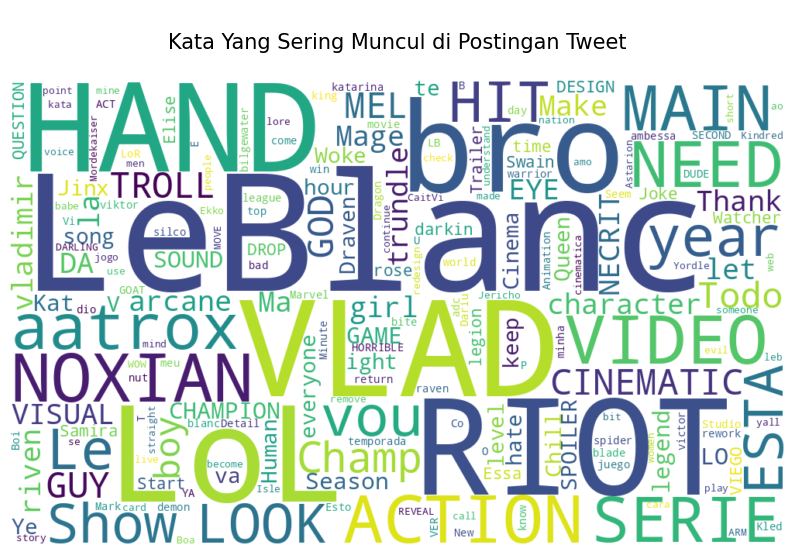

In [ ]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_reviews = " ".join(review for review in df2['cleaning'])

# Remove duplicate words
all_reviews = " ".join(set(all_reviews.split()))


wordcloud= WordCloud(width=1000, height=600, background_color='white').generate(all_reviews)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud ,interpolation='bilinear')
plt.axis('off')
plt.title('\nKata Yang Sering Muncul di Postingan Tweet\n', fontsize=15)

plt.savefig('wordcloud.png', format='png', dpi=300, bbox_inches='tight')

plt.show

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Misalnya df2 adalah DataFrame yang sudah ada dan memiliki kolom 'cleaning' yang berisi teks
# Menggabungkan seluruh teks dalam kolom 'cleaning'
all_reviews = " ".join(review for review in df2['cleaning'])

# Menghapus kata yang duplikat
all_reviews = " ".join(set(all_reviews.split()))

# Membuat WordCloud
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(all_reviews)

# Menyimpan WordCloud sebagai gambar sementara
wordcloud_image = wordcloud.to_array()

# Menampilkan gambar WordCloud menggunakan Plotly
fig = go.Figure(go.Image(z=wordcloud_image))

# Menambahkan interaktivitas
fig.update_layout(
    title="WordCloud Interaktif - Kata yang Sering Muncul",
    xaxis_visible=False,
    yaxis_visible=False,
    autosize=True
)

# Menampilkan plot interaktif
fig.show()


#### **Melihat Komentar dengan like terbanyak**

In [ ]:
def cleaning(text):
    # Fungsi untuk merapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()    # Menghapus spasi ganda dan merapikan spasi
    return text

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data tabel komentar dari dataframe df2
data = df2

# Terapkan fungsi 'cleaning' ke kolom 'textDisplay'
data['cleaned_text'] = data['textDisplay'].apply(cleaning)

# Mengurutkan data berdasarkan jumlah like
data_sorted = data.nlargest(3, 'favorite_count')

# Mendapatkan data untuk visualisasi
users = data_sorted['username']
likes = data_sorted['favorite_count']
comments = data_sorted['full_text']

# Membuat grafik batang
plt.figure(figsize=(10, 6))
plt.bar(users, likes, color='skyblue')

# Menambahkan judul dan label
plt.title('Komentar dengan Like Terbanyak', fontsize=16)
plt.xlabel('User', fontsize=14)
plt.ylabel('Jumlah Like', fontsize=14)

# Menambahkan teks komentar di atas batang
for i, comment in enumerate(comments):
    plt.text(i, likes.iloc[i] + 1, f'{likes.iloc[i]} Likes', ha='center', fontsize=12)

# Simpan grafik sebagai file PNG
plt.savefig('top_comments_likes.png', format='png', dpi=300, bbox_inches='tight')

# Tampilkan grafik
plt.show()


KeyError: 'favorite_count'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data dari dataframe df2
data = df2

# Terapkan fungsi 'cleaning' ke kolom 'textDisplay' jika diperlukan
data['cleaned_text'] = data['full_text'].apply(cleaning)

# Mengurutkan data berdasarkan jumlah like
data_sorted = data.nlargest(3, 'favorite_count')

# Mendapatkan data untuk visualisasi
users = data_sorted['username']  # Nama pengguna
komentar = data_sorted['cleaned_text']     # Menggunakan teks yang sudah dibersihkan
likes = data_sorted['favorite_count']

# Fungsi untuk membatasi panjang komentar menjadi 2 baris jika lebih dari 10 kata
def format_comment(comment):
    words = comment.split()
    if len(words) > 13:
        return " ".join(words[:13]) + "\n" + " ".join(words[13:])
    else:
        return comment

# Format komentar
formatted_comments = [format_comment(comment) for comment in komentar]

# Gabungkan user dan komentar untuk ditampilkan dengan spasi tambahan
combined_text = [f"{user}\n\n{formatted_comment}" for user, formatted_comment in zip(users, formatted_comments)]

# Membuat grafik batang dengan ukuran batang lebih kecil
plt.figure(figsize=(10, 6))
bars = plt.barh(combined_text, likes, color='skyblue', height=0.5)  # Ukuran batang yang lebih kecil

# Menambahkan judul dan label dengan ukuran font yang lebih besar
plt.title('Komentar dengan Like Terbanyak', fontsize=16, fontweight="bold")
plt.xlabel('Jumlah Like', fontsize=16, fontweight="bold")
plt.ylabel('User & Komentar', fontsize=16, fontweight="bold")

# Menambahkan jumlah like di dalam batang dengan ukuran font yang lebih besar
for bar in bars:
    width = bar.get_width()
    plt.text(width / 2, bar.get_y() + bar.get_height() / 2, f'{int(width)}',
             ha='center', va='center', color='black', fontsize=14)  # Ukuran font lebih besar

# Menyesuaikan ukuran font sumbu y untuk user dan komentar
plt.yticks(fontsize=12)  # Mengatur ukuran font untuk sumbu y

# Simpan grafik sebagai file PNG
plt.savefig('top_comments_likes.png', format='png', dpi=300, bbox_inches='tight')

# Tampilkan grafik
plt.show()


KeyError: 'full_text'

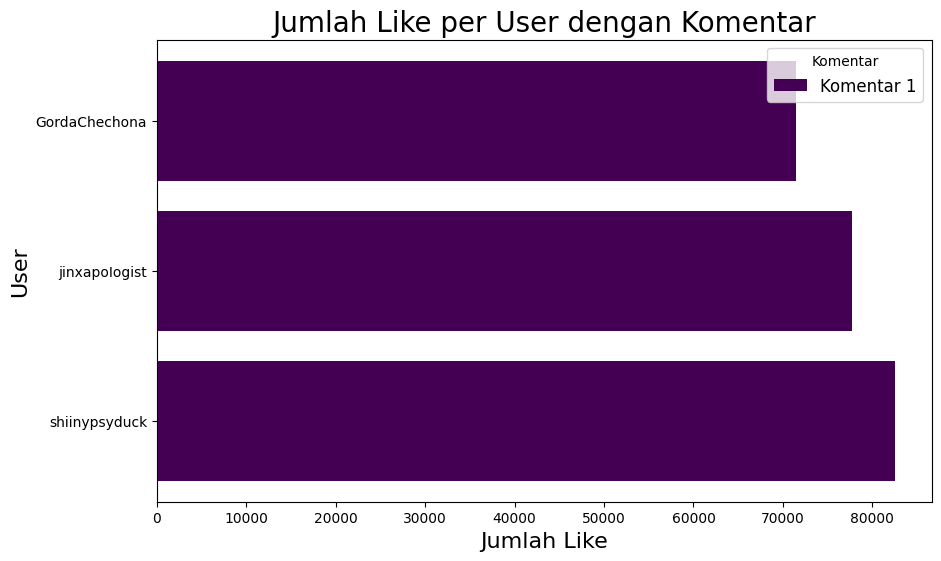

In [ ]:
import numpy as np

# Menyusun data untuk horizontal stacked bar chart
unique_users = data_sorted['username'].unique()
num_users = len(unique_users)

# Buat warna yang berbeda untuk setiap komentar
colors = plt.cm.viridis(np.linspace(0, 1, num_users))

# Menyiapkan data untuk ditampilkan dalam format stacked
stacked_likes = []
for user in unique_users:
    user_likes = data_sorted[data_sorted['username'] == user]['favorite_count'].values
    stacked_likes.append(user_likes)

# Menyusun data menjadi array numpy
stacked_likes = np.array(stacked_likes)

# Membuat grafik horizontal stacked bar chart
plt.figure(figsize=(10, 6))
bar_width = 0.5

# Plotkan setiap komentar sebagai bagian yang terpisah
for i in range(stacked_likes.shape[1]):
    plt.barh(unique_users, stacked_likes[:, i], left=stacked_likes[:, :i].sum(axis=1), color=colors[i], label=f'Komentar {i + 1}')

# Menambahkan label dan judul
plt.xlabel('Jumlah Like', fontsize=16)
plt.ylabel('User', fontsize=16)
plt.title('Jumlah Like per User dengan Komentar', fontsize=20)
plt.legend(title='Komentar', fontsize=12)

# Simpan grafik sebagai file PNG
plt.savefig('top_comments_likes_stacked.png', format='png', dpi=300, bbox_inches='tight')

# Tampilkan grafik
plt.show()


####**Clustering**

In [ ]:
# Clustering
df3=df2.drop(['full_text',	'lang', 'username',
              'remove_user',	'cleaning',	'tokenized_Content',
              'Label'], axis=1)
df3=df3.dropna()
df3.head()

,favorite_count,quote_count,reply_count,retweet_count
0,9,0.0,2.0,1.0
1,74,0.0,4.0,2.0
2,1012,1.0,14.0,68.0
3,23,0.0,3.0,5.0
4,93,6.0,3.0,17.0


In [ ]:
# Importing Standardscalar Module
from sklearn.preprocessing import StandardScaler
# Set Name for StandardScaler as scaler
scaler = StandardScaler()
# Fit Standardization
column_names = df3.columns.tolist()
df3[column_names] = scaler.fit_transform(df3[column_names])
df3.sort_index(inplace=True)
df3

,favorite_count,quote_count,reply_count,retweet_count
0,-0.247135,-0.173849,-0.200253,-0.237721
1,-0.241055,-0.173849,-0.175048,-0.236730
2,-0.153322,-0.167545,-0.049025,-0.171329
3,-0.245825,-0.173849,-0.187651,-0.233757
4,-0.239278,-0.136024,-0.187651,-0.221866
...,...,...,...,...
250,-0.161553,-0.142328,-0.086832,-0.182229
251,-0.237407,-0.173849,-0.212855,-0.232766
252,-0.139386,-0.161241,-0.175048,-0.106919
253,1.423997,0.053104,0.266032,0.338997


Text(0, 0.5, 'Retweet')

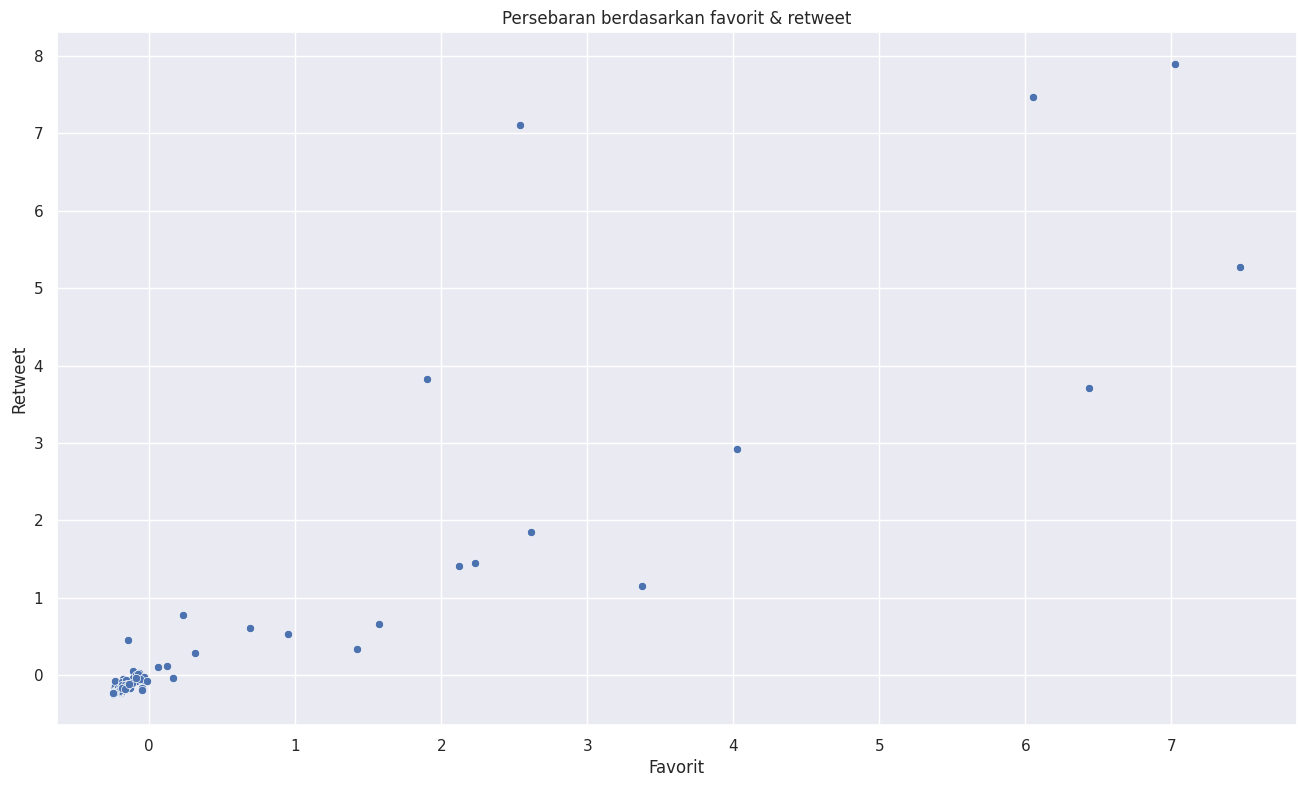

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Styling Plot
sns.set()
plt.rcParams['figure.figsize'] = (16, 9)
# Visualizing the Data
sns.scatterplot(x='favorite_count', y='retweet_count', data=df3)
plt.title('Persebaran berdasarkan favorit & retweet')
plt.xlabel('Favorit')
plt.ylabel('Retweet')

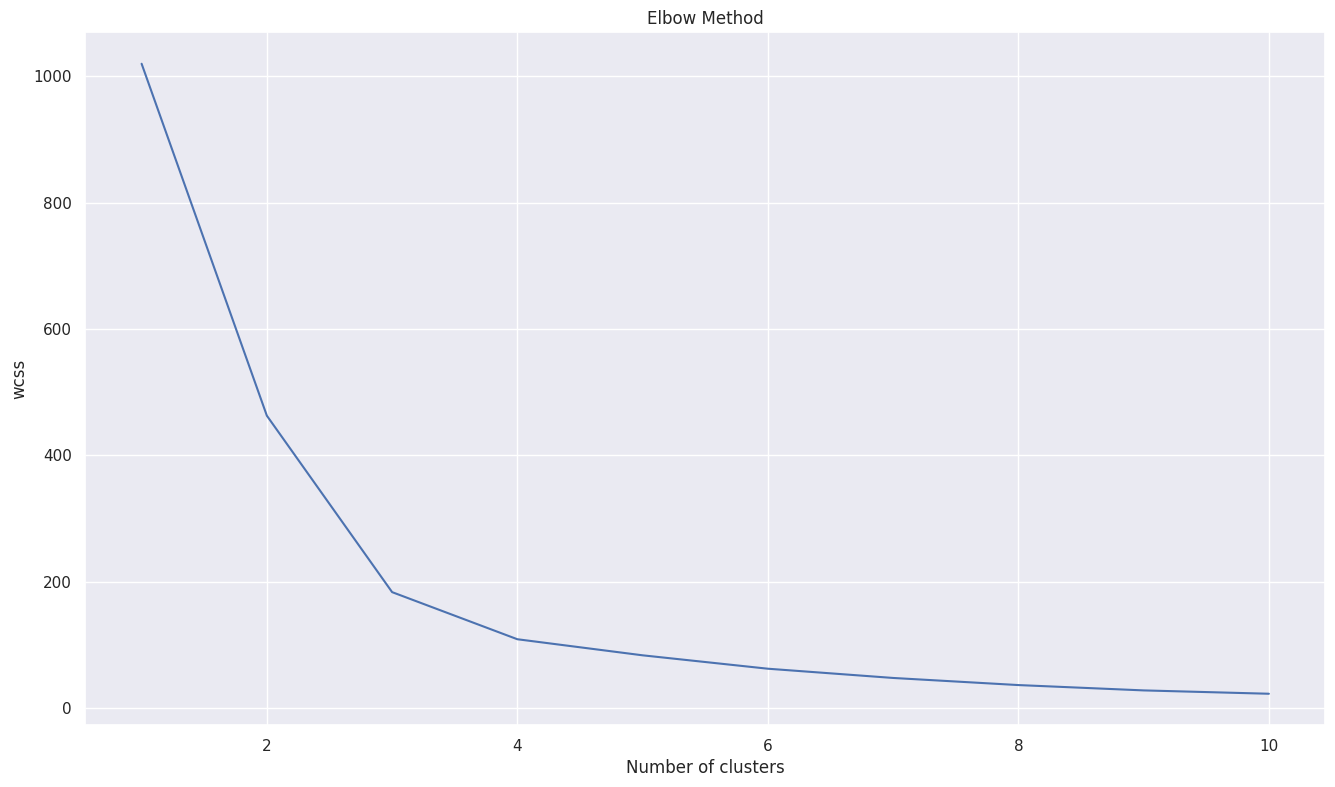

In [ ]:
# Transform Data Frame to Numpy Array
income = df3.to_numpy()
income
# Elbow Method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10,
                  random_state=0)
  kmeans.fit(income)
  wcss.append(kmeans.inertia_)
# Visualize
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
# Silhoutte Method
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
for n_cluster in range(2, 11):
  kmeans = KMeans(n_clusters=n_cluster).fit(income)
label = kmeans.labels_
sil_coeff = silhouette_score(income, label, metric='euclidean')
print('For n_clusters={}, The Silhouette Coefficient is {}'.format(n_cluster,
sil_coeff))

For n_clusters=10, The Silhouette Coefficient is 0.8242580858592888


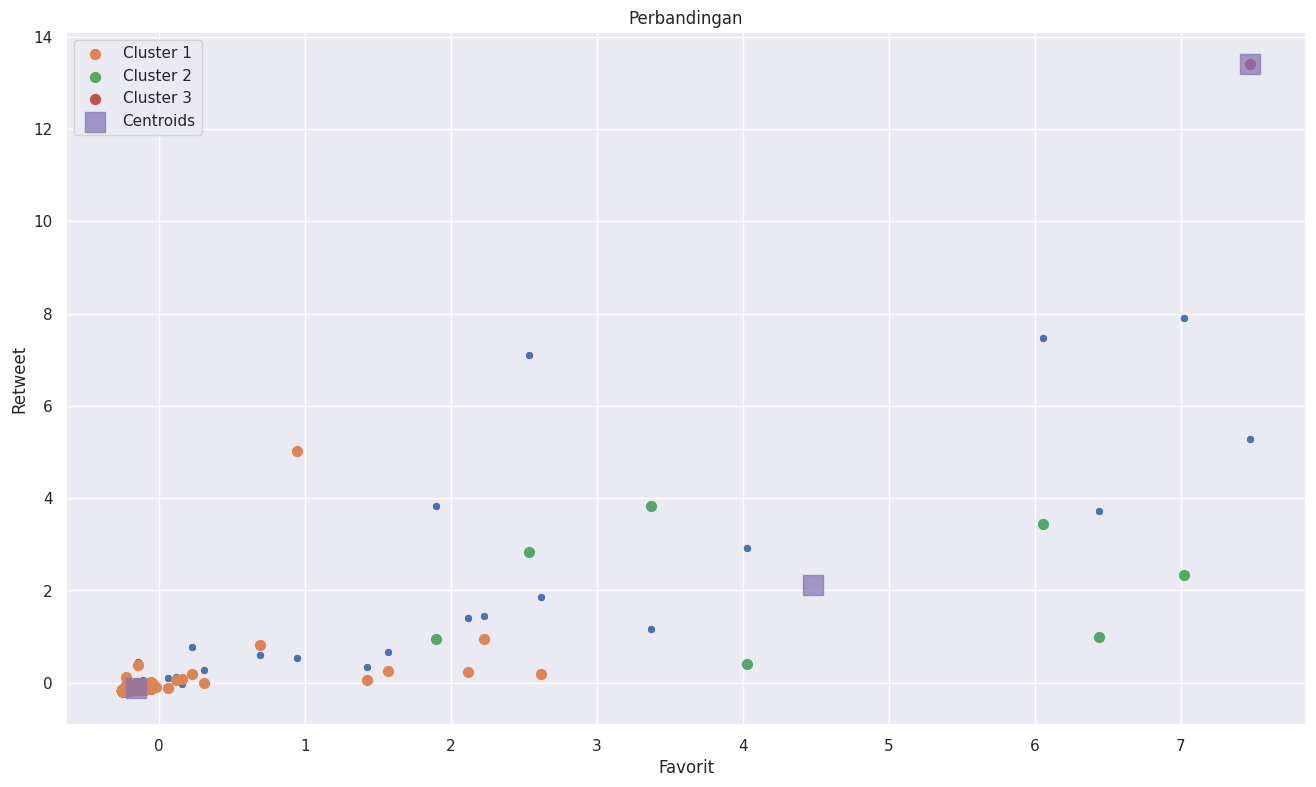

In [ ]:
# Apply the K-Means Model to the Data
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300,
n_init=10, random_state=0)
cluster = kmeans.fit_predict(income)
# Visualising Clusters for k=3
sns.scatterplot(x='favorite_count', y='retweet_count', data=df3)
plt.scatter(income[cluster == 0, 0], income[cluster == 0, 1], s = 50, label =
'Cluster 1')
plt.scatter(income[cluster == 1, 0], income[cluster == 1, 1], s = 50, label =
'Cluster 2')
plt.scatter(income[cluster == 2, 0], income[cluster == 2, 1], s = 50, label =
'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:,0],
kmeans.cluster_centers_[:,1],s=200,marker='s', alpha=0.7,
label='Centroids')
plt.title('Perbandingan')
plt.xlabel('Favorit')
plt.ylabel('Retweet')
plt.legend()
plt.show()

In [ ]:
# Add Cluster Information to the Raw Data
df3['cluster'] = cluster
df3

,favorite_count,quote_count,reply_count,retweet_count,cluster
0,-0.247135,-0.173849,-0.200253,-0.237721,0
1,-0.241055,-0.173849,-0.175048,-0.236730,0
2,-0.153322,-0.167545,-0.049025,-0.171329,0
3,-0.245825,-0.173849,-0.187651,-0.233757,0
4,-0.239278,-0.136024,-0.187651,-0.221866,0
...,...,...,...,...,...
250,-0.161553,-0.142328,-0.086832,-0.182229,0
251,-0.237407,-0.173849,-0.212855,-0.232766,0
252,-0.139386,-0.161241,-0.175048,-0.106919,0
253,1.423997,0.053104,0.266032,0.338997,0


#### **Decision Tree**

In [ ]:
# Import Data to Google Colab
df_tree=pd.read_csv('/content/ArcaneS2_Cleaned+Label.csv', sep = ',')
# Show 10 first Row
df_tree.head()

,favorite_count,full_text,lang,quote_count,reply_count,retweet_count,username,remove_user,cleaning,tokenized_Content,Label
0,9,jinx purposely not aiming at ekko.. i love you...,en,0.0,2.0,1.0,leaveinrunins,jinx purposely not aiming at ekko.. i love you...,jinx purposely not aiming at ekko i love you s...,"['""jinx""', '""purposely""', '""not""', '""aiming""',...",positif
1,74,I should've treated Jinx better...,en,0.0,4.0,2.0,orange_enforcer,I should've treated Jinx better...,I should ve treated Jinx better,"['""I""', '""should""', '""\'ve""', '""treated""', '""J...",positif
2,1012,Is it even worth it anymore,en,1.0,14.0,68.0,jinxphobia,Is it even worth it anymore,Is it even worth it anymore,"['""Is""', '""it""', '""even""', '""worth""', '""it""', ...",positif
3,23,i love jinx,en,0.0,3.0,5.0,shadowofzaun,i love jinx,i love jinx,"['""i""', '""love""', '""jinx""']",positif
4,93,I m the biggest Jinx apologist online idc she ...,en,6.0,3.0,17.0,kartoplya_arts,I m the biggest Jinx apologist online idc she ...,I m the biggest Jinx apologist online idc she ...,"['""I""', '""m""', '""the""', '""biggest""', '""Jinx""',...",positif


In [ ]:
# Replace Churn Values
df_tree['Label'].replace(['negatif', 'positif'], [0,1], inplace=True)
# Show Data
df_tree.head(3)

,favorite_count,full_text,lang,quote_count,reply_count,retweet_count,username,remove_user,cleaning,tokenized_Content,Label
0,9,jinx purposely not aiming at ekko.. i love you...,en,0.0,2.0,1.0,leaveinrunins,jinx purposely not aiming at ekko.. i love you...,jinx purposely not aiming at ekko i love you s...,"['""jinx""', '""purposely""', '""not""', '""aiming""',...",1
1,74,I should've treated Jinx better...,en,0.0,4.0,2.0,orange_enforcer,I should've treated Jinx better...,I should ve treated Jinx better,"['""I""', '""should""', '""\'ve""', '""treated""', '""J...",1
2,1012,Is it even worth it anymore,en,1.0,14.0,68.0,jinxphobia,Is it even worth it anymore,Is it even worth it anymore,"['""Is""', '""it""', '""even""', '""worth""', '""it""', ...",1


In [ ]:
# Import Standard Scaler
from sklearn.preprocessing import StandardScaler
# Initizalize Standard Scaler
standard_scaler = StandardScaler()
df_stand = df_tree.copy()
# Transform all attributes
df_stand[column_names] = standard_scaler.fit_transform(df_stand[column_names])
df_stand.sort_index(inplace=True)
df_stand.head()

,favorite_count,full_text,lang,quote_count,reply_count,retweet_count,username,remove_user,cleaning,tokenized_Content,Label
0,-0.247135,jinx purposely not aiming at ekko.. i love you...,en,-0.173849,-0.200253,-0.237721,leaveinrunins,jinx purposely not aiming at ekko.. i love you...,jinx purposely not aiming at ekko i love you s...,"['""jinx""', '""purposely""', '""not""', '""aiming""',...",1
1,-0.241055,I should've treated Jinx better...,en,-0.173849,-0.175048,-0.236730,orange_enforcer,I should've treated Jinx better...,I should ve treated Jinx better,"['""I""', '""should""', '""\'ve""', '""treated""', '""J...",1
2,-0.153322,Is it even worth it anymore,en,-0.167545,-0.049025,-0.171329,jinxphobia,Is it even worth it anymore,Is it even worth it anymore,"['""Is""', '""it""', '""even""', '""worth""', '""it""', ...",1
3,-0.245825,i love jinx,en,-0.173849,-0.187651,-0.233757,shadowofzaun,i love jinx,i love jinx,"['""i""', '""love""', '""jinx""']",1
4,-0.239278,I m the biggest Jinx apologist online idc she ...,en,-0.136024,-0.187651,-0.221866,kartoplya_arts,I m the biggest Jinx apologist online idc she ...,I m the biggest Jinx apologist online idc she ...,"['""I""', '""m""', '""the""', '""biggest""', '""Jinx""',...",1


In [ ]:
feature = df_stand.drop(['full_text',	'lang', 'username',	'remove_user',	'cleaning',	'tokenized_Content'], axis=1)
feature

,favorite_count,quote_count,reply_count,retweet_count,Label
0,-0.247135,-0.173849,-0.200253,-0.237721,1
1,-0.241055,-0.173849,-0.175048,-0.236730,1
2,-0.153322,-0.167545,-0.049025,-0.171329,1
3,-0.245825,-0.173849,-0.187651,-0.233757,1
4,-0.239278,-0.136024,-0.187651,-0.221866,1
...,...,...,...,...,...
250,-0.161553,-0.142328,-0.086832,-0.182229,0
251,-0.237407,-0.173849,-0.212855,-0.232766,0
252,-0.139386,-0.161241,-0.175048,-0.106919,0
253,1.423997,0.053104,0.266032,0.338997,1


In [ ]:
# Select Target
target = df_stand['Label']
target

,Label
0,1
1,1
2,1
3,1
4,1
...,...
250,0
251,0
252,0
253,1


In [ ]:
# Set Training and Testing Data (70:30)
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(feature , target, shuffle
= True, test_size=0.3, random_state=1)
# Show the Training and Testing Data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(178, 5)
(77, 5)
(178,)
(77,)


In [ ]:
# Import Module
from sklearn import tree
# Modeling Decision Tree

In [ ]:
dtc = tree.DecisionTreeClassifier(min_impurity_decrease=0.01)
dtc.fit(X_train, y_train)
# Predict to Test Data
y_pred_dtc = dtc.predict(X_test)

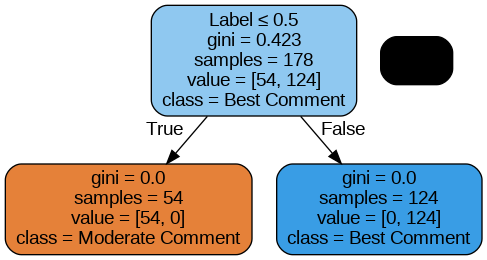

In [ ]:
# Visualize Tree
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(dtc, out_file=dot_data, filled=True, rounded=True, special_characters=True,
                class_names=['Moderate Comment', 'Best Comment'],
                feature_names=['favorite_count',	'quote_count',	'reply_count',	'retweet_count',	'Label'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
# Import Module
from sklearn import metrics
# Show the Confussion Matrix
cm_dtc = metrics.confusion_matrix(y_test, y_pred_dtc)
cm_dtc

array([[22,  0],
       [ 0, 55]])

In [ ]:
from sklearn import metrics

# Calculate metrics with multiclass handling
acc_dtc = metrics.accuracy_score(y_test, y_pred_dtc)
prec_dtc = metrics.precision_score(y_test, y_pred_dtc, average='weighted')  # Specify 'micro', 'macro', or 'weighted'
rec_dtc = metrics.recall_score(y_test, y_pred_dtc, average='weighted')      # Specify 'micro', 'macro', or 'weighted'
f1_dtc = metrics.f1_score(y_test, y_pred_dtc, average='weighted')           # Specify 'micro', 'macro', or 'weighted'
kappa_dtc = metrics.cohen_kappa_score(y_test, y_pred_dtc)

# Print the results
print("Accuracy:", acc_dtc)
print("Precision:", prec_dtc)
print("Recall:", rec_dtc)
print("F1 Score:", f1_dtc)
print("Cohen's Kappa:", kappa_dtc)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Cohen's Kappa: 1.0


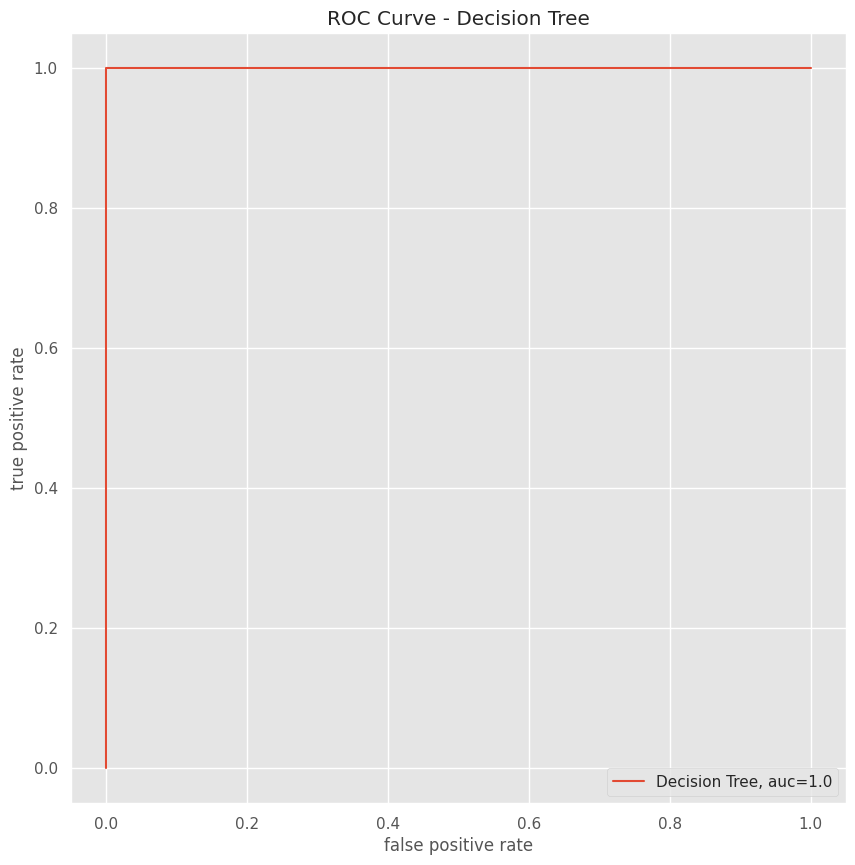

In [ ]:
# Import Visualization Package
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Set Size and Style
plt.rcParams['figure.figsize'] = (10, 10)
plt.style.use('ggplot')
# Visualize ROC Curve
y_pred_dtc_proba = dtc.predict_proba(X_test)[::,1]
fprdtc, tprdtc, _ = metrics.roc_curve(y_test, y_pred_dtc_proba)
aucdtc = metrics.roc_auc_score(y_test, y_pred_dtc_proba)
plt.plot(fprdtc,tprdtc,label="Decision Tree, auc="+str(aucdtc))
plt.title('ROC Curve - Decision Tree')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend(loc=4)
plt.show()

#### **Scattering**

In [ ]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data to Google Colab
dfreg=pd.read_csv('/content/ArcaneS2_Cleaned+Label.csv', sep = ',')
# Show 10 first Row
dfreg.head(3)

,favorite_count,full_text,lang,quote_count,reply_count,retweet_count,username,remove_user,cleaning,tokenized_Content,Label
0,9,jinx purposely not aiming at ekko.. i love you...,en,0.0,2.0,1.0,leaveinrunins,jinx purposely not aiming at ekko.. i love you...,jinx purposely not aiming at ekko i love you s...,"['""jinx""', '""purposely""', '""not""', '""aiming""',...",positif
1,74,I should've treated Jinx better...,en,0.0,4.0,2.0,orange_enforcer,I should've treated Jinx better...,I should ve treated Jinx better,"['""I""', '""should""', '""\'ve""', '""treated""', '""J...",positif
2,1012,Is it even worth it anymore,en,1.0,14.0,68.0,jinxphobia,Is it even worth it anymore,Is it even worth it anymore,"['""Is""', '""it""', '""even""', '""worth""', '""it""', ...",positif


In [ ]:
import plotly.express as px

# Membuat scatter plot interaktif
fig = px.scatter(dfreg,
                 x='favorite_count',  # Sumbu X (jumlah like)
                 y='retweet_count',   # Sumbu Y (jumlah retweet)
                 color='Label',       # Warna berdasarkan kolom 'Label' (kategori)
                 size='favorite_count',  # Ukuran titik berdasarkan jumlah like
                 hover_name='Label',  # Menampilkan 'Label' saat mengarahkan kursor ke titik
                 hover_data={'username': True},  # Menampilkan kolom 'username' saat hover
                 title='Scatter Plot Interaktif antara Like dan Retweet',  # Judul plot
                 labels={'favorite_count': 'Jumlah Like', 'retweet_count': 'Jumlah Retweet'}  # Label sumbu

)

# Menampilkan plot interaktif
fig.show()

# **LANJUTAN**

In [ ]:
import pandas as pd

# Membaca data tabel komentar dari file CSV
data = df2

# Menghitung jumlah tag untuk setiap nama
tag_counts = data['authorDisplayName'].value_counts()

# Menampilkan nama yang paling banyak di-tag
most_tagged = tag_counts.idxmax()
top_three_tagged = tag_counts.nlargest(3)

print("Tiga orang yang paling banyak di-tag:\n")
print(top_three_tagged)

NameError: name 'df2' is not defined

In [ ]:
import pandas as pd

# Membaca data tabel komentar dari file CSV
data = df2

data[''] = data['textDisplay'].apply(cleaning)

# Mengurutkan data berdasarkan jumlah like
data_sorted = data.nlargest(3, 'likeCount')
print('Komentar dengan like terbanyak\n')
# Menampilkan tiga komentar dengan like terbanyak
for index, row in data_sorted.iterrows():
    user = row['authorDisplayName']
    komentar = row['textDisplay']
    jumlah_like = row['likeCount']
    print('<><><><><><><><><><>')
    print()
    print('User:', user)
    print()
    print("Komentar:", komentar)
    print()
    print("Jumlah Like:", jumlah_like)
    print()
    print("--------------------")

Komentar dengan like terbanyak

<><><><><><><><><><>

User: @volcyr8721

Komentar: 17sec scream  'this is what you asked for '  shivers been sent.

Jumlah Like: 13535

--------------------
<><><><><><><><><><>

User: @Valle

Komentar: 2 Songs - 2 absolute bangers. Gotta love it..

Jumlah Like: 10879

--------------------
<><><><><><><><><><>

User: @andrekenjisouza

Komentar: I 'm really impressed by how this sounds Linkin Park in every way.   It 's almost a mist of Meteora / Living Things / THP.

Jumlah Like: 5276

--------------------


In [ ]:
import pandas as pd
from PyQt5.QtWidgets import QApplication, QWidget, QVBoxLayout, QPushButton, QTextEdit

# Dummy data untuk simulasi
data = pd.DataFrame({
    'authorDisplayName': ['User1', 'User2', 'User3', 'User4'],
    'textDisplay': ['Komentar pertama', 'Komentar kedua', 'Komentar ketiga', 'Komentar keempat'],
    'likeCount': [10, 50, 20, 30]
})

class KomentarApp(QWidget):
    def __init__(self):
        super().__init__()

        self.initUI()

    def initUI(self):
        self.setWindowTitle('Komentar Terbanyak')

        # Layout utama
        layout = QVBoxLayout()

        # Tombol untuk menampilkan komentar
        self.btn = QPushButton('Tampilkan Komentar Terbanyak', self)
        self.btn.clicked.connect(self.tampilkan_komentar)

        # Text area untuk menampilkan komentar
        self.text_area = QTextEdit(self)
        self.text_area.setReadOnly(True)

        layout.addWidget(self.btn)
        layout.addWidget(self.text_area)

        self.setLayout(layout)

    def tampilkan_komentar(self):
        # Mengurutkan data berdasarkan jumlah like
        data_sorted = data.nlargest(3, 'likeCount')

        # Menampilkan komentar pada text area
        self.text_area.clear()
        for index, row in data_sorted.iterrows():
            user = row['authorDisplayName']
            komentar = row['textDisplay']
            jumlah_like = row['likeCount']
            self.text_area.append(f"User: {user}")
            self.text_area.append(f"Komentar: {komentar}")
            self.text_area.append(f"Jumlah Like: {jumlah_like}")
            self.text_area.append("--------------------")

if __name__ == '__main__':
    import sys
    app = QApplication(sys.argv)
    ex = KomentarApp()
    ex.show()
    sys.exit(app.exec_())
